# Hybrid Retrieval with Reciprocal Rank Fusion

**Docker image**: `ml4t-gpu`

**Chapter 22: RAG for Financial Research** (Section 22.5)

Four retrieval stacks over one corpus of 10-K passages: BM25, dense
embeddings, the two fused by reciprocal rank fusion, and that fusion
reranked by a cross-encoder.

The scores they are ranked by come from a term-overlap rule, because nobody
has annotated this corpus. That rule reads the same signal BM25 reads, and
the section that measures how much says so before any ranking is reported.
The result is not that one retriever wins. It is that a lexical label rule
cannot be used to choose between a lexical retriever and a semantic one, and
this notebook shows what that looks like from the inside.

**Learning objectives**

After working through this notebook you will be able to:

- Implement BM25 from the formula, dense retrieval from a pinned encoder,
  and reciprocal rank fusion over the two, without a retrieval library.
- Say what reciprocal rank fusion does that a weighted score blend does not,
  and why that matters when two retrievers score on different scales.
- Measure the dependence between a proxy label rule and a retriever scored
  against it, and recognise the circularity when a benchmark has it.
- Read a Precision@k against its ceiling rather than against one.
- Say why a cross-encoder reranker can lower a benchmark score while
  improving the ranking.

**Prerequisites**

- The SP100 10-K corpus, read through `data.load_sec_filings`.
  [`01_sec_filing_pipeline`](01_sec_filing_pipeline.ipynb) establishes what
  the stored text is; these passages inherit it.
- `sentence-transformers` and a CUDA GPU. `REQUIRE_GPU` refuses a CPU run.
- [`02_domain_embeddings_comparison`](02_domain_embeddings_comparison.ipynb)
  builds the same kind of proxy and measures a different weakness in it.

**Book reference**: Section 22.5, on hybrid retrieval architectures, the RRF
derivation, and vector database selection criteria.

## Setup

These parameters control query count and retrieval depth so the comparison
stays reproducible across lexical, dense, fused, and reranked pipelines.

In [1]:
"""Hybrid Retrieval - BM25 + semantic search with Reciprocal Rank Fusion."""

import re
from collections import defaultdict

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch

# Visualization
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

# ML4T configuration
from data import load_sec_filings
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
MAX_QUERIES = 0
MAX_DOCUMENTS = 0
TOP_K = 10
BM25_K1 = 1.5  # how fast repeated terms stop adding score
BM25_B = 0.75  # how much a long document is penalised for its length
RRF_K = 60  # rank offset in the fusion; larger flattens the top of each list
RERANK_CANDIDATES = 50
FINAL_TOP_K = 5
REQUIRE_GPU = True
SEED = 42
# Pinned so a re-run cannot silently change the encoder underneath the scores.
DENSE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
DENSE_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
CROSS_ENCODER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
CROSS_ENCODER_REVISION = "c5ee24cb16019beea0893ab7796b1df96625c6b8"

The seeding stays immediately after the parameters cell: a papermill `SEED`
override has to take effect before anything consumes randomness.

In [3]:
set_global_seeds(SEED)

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("This production retrieval benchmark requires a CUDA-capable GPU.")
RETRIEVAL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dense retrieval device: {RETRIEVAL_DEVICE}")

Dense retrieval device: cuda


In [4]:
print(f"Query cap: {MAX_QUERIES if MAX_QUERIES > 0 else 'all configured queries'}")
print(f"Top-K retrieval: {TOP_K}")

Query cap: all configured queries
Top-K retrieval: 10


`RERANK_CANDIDATES` is the pool the cross-encoder scores and `FINAL_TOP_K` is
the cut a production pipeline would hand to generation, following the
chapter's retrieve-rerank-generate pattern. The single-stage retrievers are
still evaluated at `TOP_K`, so all four
methods are scored at the same depth whatever the production cut would be.

## 1. The corpus and the labels

We load real 10-K filing text from the SP100 corpus and chunk it into
retrieval-ready passages. The chunks naturally contain exact terms (symbol
symbols, accession numbers), conceptual content (risk factors, competition),
and mixed language - matching how analysts actually search filings.

`TOP_K` decides how much room each retriever has to surface a labelled
document, and therefore how forgiving every metric below is.

In [5]:
# Load real 10-K filing chunks from SP100 corpus via the canonical loader
SAMPLE_SYMBOLS = ["AAPL", "MSFT", "AMZN", "JNJ", "BA", "ADBE", "ABT", "AMGN"]
filings_df = (
    load_sec_filings(form_type="10-K", universe="sp100", symbols=SAMPLE_SYMBOLS)
    .sort(["filing_date", "symbol"], descending=[True, False])
    .unique(subset=["symbol"], keep="first")
    .sort("symbol")
)

raw_chunks = []
for row in filings_df.iter_rows(named=True):
    symbol = row["symbol"]
    text = row["text"]
    if not text or len(text) < 200:
        continue
    sentences = [s.strip() for s in text.replace("\n", " ").split(". ") if len(s.strip()) > 40]
    for j in range(0, len(sentences) - 1, 2):
        chunk = ". ".join(sentences[j : j + 2]) + "."
        if 80 < len(chunk) < 600:
            raw_chunks.append({"symbol": symbol, "text": f"[{symbol}] {chunk}"})

print(f"Chunked {len(raw_chunks)} passages from filing corpus")

Chunked 203 passages from filing corpus


### Select a reproducible document sample

This helper isolates seeded sampling and stable document-ID assignment from
the corpus materialization step that follows.

In [6]:
def sample_document_corpus(
    chunks: list[dict], max_documents: int, seed: int
) -> list[dict[str, str]]:
    """Select a seeded corpus and assign stable IDs in source order."""
    rng = np.random.default_rng(seed)
    n_docs = min(max_documents if max_documents > 0 else 200, len(chunks))
    sample_idx = rng.choice(len(chunks), size=n_docs, replace=False)
    return [
        {"id": f"doc_{i + 1:03d}", "text": chunks[idx]["text"], "source": "10k_filing"}
        for i, idx in enumerate(sorted(sample_idx))
    ]

### Materialize the retrieval corpus

Apply the seeded selector once, then expose aligned text and document-ID
arrays to every retrieval method. Two hundred passages is enough for both
retrievers to have somewhere to be wrong, and small enough that the
cross-encoder pass stays under a minute.

In [7]:
DOCUMENT_CORPUS = sample_document_corpus(raw_chunks, MAX_DOCUMENTS, SEED)

documents = [d["text"] for d in DOCUMENT_CORPUS]
doc_ids = [d["id"] for d in DOCUMENT_CORPUS]

print(f"Document corpus: {len(documents)} documents")

Document corpus: 200 documents


### The labels, and what they are made of

Nobody has annotated this corpus, so relevance is a rule: count the query
tokens longer than three characters that appear in a document, and call the
three highest-scoring documents relevant, breaking ties on the document id.

Read that rule next to BM25, which the notebook builds two sections below.
BM25 also counts query tokens appearing in a document; it weights them by
inverse document frequency and normalises for document length, and that is
the whole of the difference. The label rule is an unweighted BM25.

So one of the four retrievers about to be compared is a simplification of
the thing scoring them. A section after the evaluation measures how much
that is worth, and it is worth a lot.

In [8]:
def lexical_token_set(text: str) -> set[str]:
    """Return normalized lexical tokens used by the proxy-label contract."""
    return {token for token in re.findall(r"\b\w+\b", text.lower()) if len(token) > 3}

### Rank documents by exact token overlap

The selector uses the shared token contract and an immutable document-ID
tie-break to create at most three proxy-relevant documents per query.

In [9]:
def find_proxy_docs(query: str, corpus: list[dict]) -> list[str]:
    """Return up to three documents with the highest positive lexical overlap."""
    query_terms = lexical_token_set(query)
    scored = []
    for doc in corpus:
        overlap = len(query_terms & lexical_token_set(doc["text"]))
        if overlap > 0:
            scored.append((overlap, doc["id"]))
    scored.sort(key=lambda item: (-item[0], item[1]))
    return [doc_id for _overlap, doc_id in scored[:3]]

### Build the labelled query set

The three query types (exact, conceptual, mixed) are paired with their
pseudo-relevance labels so each retriever can be scored against the same
proxy ground truth.

In [10]:
# Test queries grounded in real 10-K filing content
TEST_QUERIES = []
query_specs = [
    # Queries naming a company or a concrete artefact.
    ("How does Apple compete against low-cost competitors?", "exact"),
    ("What intellectual property protections does the company have?", "exact"),
    ("What are the company's product development capabilities?", "exact"),
    ("pharmaceutical products and regulatory requirements", "exact"),
    ("aircraft defense manufacturing operations", "exact"),
    # The same subject matter phrased without a name to key on.
    ("What competitive threats does the company face?", "conceptual"),
    ("How does the company protect against imitation?", "conceptual"),
    ("What risks affect the company's technology strategy?", "conceptual"),
    ("How does the company develop innovative products?", "conceptual"),
    ("What operational challenges exist in manufacturing?", "conceptual"),
    # Keyword-style fragments rather than questions.
    ("company hardware software integration strategy", "mixed"),
    ("customer acquisition costs and retention", "mixed"),
    ("supply chain risk management approach", "mixed"),
    ("regulatory compliance investment requirements", "mixed"),
    ("market share competition pricing pressure", "mixed"),
]

for query, qtype in query_specs:
    relevant = find_proxy_docs(query, DOCUMENT_CORPUS)
    if not relevant:
        raise ValueError(f"No positive lexical overlap for query: {query}")
    TEST_QUERIES.append((query, qtype, relevant))

if MAX_QUERIES > 0:
    TEST_QUERIES = TEST_QUERIES[:MAX_QUERIES]

N_QUERIES = len(TEST_QUERIES)
print(f"Test queries: {N_QUERIES}")

Test queries: 15


The three registers are a design choice about phrasing, not a property of the
queries that anything here verifies. They are grouped this way because the
usual expectation is that literal phrasing suits BM25 and paraphrase suits a
dense encoder. Whether the numbers bear that out is the question section 7
asks, and the answer is no.

## 2. BM25 Implementation

BM25 (Best Matching 25) is a bag-of-words retrieval function that ranks
documents based on term frequency and inverse document frequency.

It has two constants, both declared in the parameters cell:

- `BM25_K1` decides how quickly a repeated term stops adding score. Low
  values mean a second occurrence is worth much less than the first.
- `BM25_B` decides how much a long document is penalised for its length,
  from none at zero to fully proportional at one.

In [11]:
def bm25_tokenize(text: str) -> list[str]:
    """Split on word boundaries and lowercase - the token contract BM25 scores on."""
    return re.findall(r"\b\w+\b", text.lower())

### Corpus statistics for BM25

Precompute token counts and document frequencies once so scoring stays simple.


In [12]:
def build_bm25_index(
    documents: list[str],
) -> tuple[list[list[str]], set[str], dict[str, int], list[int], float]:
    """Tokenize the corpus and compute document-frequency statistics."""
    doc_tokens = [bm25_tokenize(doc) for doc in documents]
    vocab: set[str] = set()
    doc_freqs: dict[str, int] = defaultdict(int)
    doc_lens: list[int] = []

    for tokens in doc_tokens:
        doc_lens.append(len(tokens))
        unique_tokens = set(tokens)
        vocab.update(unique_tokens)
        for token in unique_tokens:
            doc_freqs[token] += 1

    avgdl = float(np.mean(doc_lens))
    return doc_tokens, vocab, doc_freqs, doc_lens, avgdl

### BM25 scoring

Score one query against the whole corpus using the standard BM25 formula and
keep the scoring mechanics visible for later debugging.


In [13]:
def compute_bm25_scores(
    query: str,
    doc_tokens: list[list[str]],
    doc_freqs: dict[str, int],
    doc_lens: list[int],
    avgdl: float,
    k1: float,
    b: float,
) -> np.ndarray:
    """Score the full corpus for one query using the BM25 formula."""
    query_tokens = bm25_tokenize(query)
    n_docs = len(doc_tokens)
    scores = np.zeros(n_docs)

    for i, tokens in enumerate(doc_tokens):
        doc_len = doc_lens[i]
        term_freqs = defaultdict(int)
        for token in tokens:
            term_freqs[token] += 1

        for q_term in query_tokens:
            df = doc_freqs.get(q_term)
            if df is None:
                continue
            tf = term_freqs[q_term]
            idf = np.log((n_docs - df + 0.5) / (df + 0.5) + 1)
            numerator = tf * (k1 + 1)
            denominator = tf + k1 * (1 - b + b * doc_len / avgdl)
            scores[i] += idf * numerator / denominator

    return scores

### Build compact display previews

This helper truncates only the reader-facing preview. The full passage remains
available for retrieval evaluation and downstream cross-encoder scoring.


In [14]:
def passage_preview(text: str, limit: int = 100) -> str:
    """Return a compact display preview without altering scoring text."""
    suffix = "..." if len(text) > limit else ""
    return text[:limit] + suffix

### Preserve full retrieval records

Retrieval results carry full scoring text and a separate compact preview so
display formatting cannot alter later model inputs.

In [15]:
def make_retrieval_result(rank: int, doc_id: str, score: float, text: str) -> dict:
    """Keep the full passage for downstream scoring and add a display preview."""
    return {
        "rank": rank,
        "doc_id": doc_id,
        "score": score,
        "text": text,
        "preview": passage_preview(text),
    }

### Wrap the BM25 scoring primitives

The retriever stores corpus statistics, applies deterministic document-ID
tie-breaks, and emits the shared full-text result schema.

In [16]:
class BM25Retriever:
    """BM25 retrieval implementation for exact lexical matching."""

    def __init__(self, documents: list, k1: float = BM25_K1, b: float = BM25_B):
        self.documents = documents
        self.k1 = k1
        self.b = b
        self.doc_tokens, self.vocab, self.doc_freqs, self.doc_lens, self.avgdl = build_bm25_index(
            documents
        )

    def score(self, query: str) -> np.ndarray:
        return compute_bm25_scores(
            query, self.doc_tokens, self.doc_freqs, self.doc_lens, self.avgdl, self.k1, self.b
        )

    def retrieve(self, query: str, top_k: int = 5) -> list:
        scores = self.score(query)
        top_indices = sorted(
            range(len(scores)), key=lambda index: (-float(scores[index]), doc_ids[index])
        )[:top_k]
        return [
            make_retrieval_result(rank + 1, doc_ids[idx], scores[idx], self.documents[idx])
            for rank, idx in enumerate(top_indices)
        ]

In [17]:
# Initialize BM25 retriever
bm25 = BM25Retriever(documents)
print(f"BM25 index built: {len(bm25.vocab)} unique terms")

# Test query
test_result = bm25.retrieve("AAPL revenue Q4 2023", top_k=3)
print("\nBM25 test query: 'AAPL revenue Q4 2023'")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.3f})")

BM25 index built: 2111 unique terms

BM25 test query: 'AAPL revenue Q4 2023'
  1. doc_121 (score: 6.141)
  2. doc_061 (score: 5.108)
  3. doc_154 (score: 3.612)


A term the corpus contains rarely gets a high inverse document frequency, so
a query carrying one pulls the passages containing it to the top. That is
what makes BM25 hard to replace for filings, where a form number or a ticker
is often the whole of what distinguishes the right passage.

## 3. Semantic Retrieval with Embeddings

Semantic search uses dense embeddings to capture meaning beyond
exact keyword matches. Useful for:
- Paraphrased queries
- Conceptual similarity
- Cross-lingual retrieval

In [18]:
def build_semantic_index(documents: list[str], model_name: str) -> tuple[object, np.ndarray]:
    """Create dense document embeddings via sentence-transformers."""
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(model_name, revision=DENSE_REVISION, device=RETRIEVAL_DEVICE)
    parameter_device = next(model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"Dense encoder parameters are on {parameter_device}, not CUDA.")
    embeddings = model.encode(documents, show_progress_bar=False)
    print(f"Semantic index built: {embeddings.shape}; parameters={parameter_device}")
    return model, embeddings

The device line is a check, not decoration: a model that silently fell back
to CPU would still produce numbers, and `REQUIRE_GPU` refuses that rather
than letting the run take an hour and go unremarked.

### Semantic similarity scoring

Compare one query embedding to the precomputed corpus embeddings so the dense
retriever remains transparent about how its similarity scores are formed.


In [19]:
def semantic_similarity_scores(query: str, model, embeddings: np.ndarray) -> np.ndarray:
    """Compute cosine similarity between one query and the embedded corpus."""
    query_embedding = model.encode([query], show_progress_bar=False)[0]
    doc_norms = np.linalg.norm(embeddings, axis=1)
    query_norm = np.linalg.norm(query_embedding)
    return np.dot(embeddings, query_embedding) / (doc_norms * query_norm + 1e-8)

### Semantic Retriever Wrapper

The wrapper keeps the notebook API parallel to BM25 while the embedding and
scoring helpers make the dense retrieval steps explicit.


In [20]:
class SemanticRetriever:
    """Semantic retrieval using dense embeddings and cosine similarity."""

    def __init__(self, documents: list, model_name: str = DENSE_MODEL):
        self.documents = documents
        self.model_name = model_name
        self.model, self.embeddings = build_semantic_index(documents, model_name)

    def score(self, query: str) -> np.ndarray:
        return semantic_similarity_scores(query, self.model, self.embeddings)

    def retrieve(self, query: str, top_k: int = 5) -> list:
        scores = self.score(query)
        top_indices = sorted(
            range(len(scores)), key=lambda index: (-float(scores[index]), doc_ids[index])
        )[:top_k]
        return [
            make_retrieval_result(rank + 1, doc_ids[idx], scores[idx], self.documents[idx])
            for rank, idx in enumerate(top_indices)
        ]

In [21]:
# Initialize semantic retriever
semantic = SemanticRetriever(documents)

# Test query
test_result = semantic.retrieve("What are the main risks facing the company?", top_k=3)
print("\nSemantic test query: 'What are the main risks facing the company?'")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.3f})")

Semantic index built: (200, 384); parameters=cuda:0

Semantic test query: 'What are the main risks facing the company?'
  1. doc_029 (score: 0.662)
  2. doc_080 (score: 0.620)
  3. doc_030 (score: 0.602)


The dense retriever returns passages that share no distinctive term with the
query. Whether that is better is what the evaluation is for; what it is, is
different, and a fusion of two retrievers is only worth building when they
disagree.

## 4. Reciprocal Rank Fusion (RRF)

RRF combines ranked lists from multiple retrievers into a single
ranking. The key formula:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

Where:
- $R$ is the set of retrieval methods
- $k$ is a constant (typically 60) that dampens the influence of high ranks
- $\text{rank}_r(d)$ is the rank of document $d$ in retriever $r$

**Benefits of RRF:**
- No learned fusion weights; this notebook fixes k=60
- Robust to score scale differences
- Handles non-overlapping results gracefully

### RRF Scoring Function

The core fusion algorithm: for each document, sum the reciprocal of its
rank across all retriever lists. The constant $k=60$ dampens the influence
of top-ranked results, making the fusion more robust.

In [22]:
def reciprocal_rank_fusion(ranked_lists: list[list], k: int = RRF_K) -> list:
    """
    Combine multiple ranked lists using Reciprocal Rank Fusion.

    Args:
        ranked_lists: List of ranked document ID lists [[doc1, doc2, ...], ...]
        k: Smoothing constant (default 60)

    Returns:
        Fused ranking as list of (doc_id, rrf_score) tuples
    """
    rrf_scores = defaultdict(float)

    for ranked_list in ranked_lists:
        for rank, doc_id in enumerate(ranked_list, 1):
            rrf_scores[doc_id] += 1.0 / (k + rank)

    sorted_docs = sorted(rrf_scores.items(), key=lambda item: (-item[1], item[0]))
    return sorted_docs

### Hybrid Retriever

Combines BM25 and semantic retrieval by running both, then fusing their
ranked lists via RRF. Each retriever fetches `2 * top_k` candidates to
ensure sufficient overlap for meaningful fusion.

In [23]:
def format_fused_results(fused: list[tuple[str, float]], top_k: int) -> list:
    """Attach full scoring text and separate previews to fused identities."""
    results = []
    for doc_id, rrf_score in fused[:top_k]:
        doc_idx = doc_ids.index(doc_id)
        results.append(
            make_retrieval_result(
                len(results) + 1,
                doc_id,
                rrf_score,
                documents[doc_idx],
            )
        )
    return results

### Combine lexical and semantic rankings

The hybrid retriever runs both first-stage methods over the same corpus and
applies fixed-k reciprocal-rank fusion to their ordered document identities.

In [24]:
class HybridRetriever:
    """
    Hybrid retrieval combining BM25 and semantic search with RRF.
    """

    def __init__(
        self,
        bm25_retriever: BM25Retriever,
        semantic_retriever: SemanticRetriever,
        rrf_k: int = RRF_K,
    ):
        self.bm25 = bm25_retriever
        self.semantic = semantic_retriever
        self.rrf_k = rrf_k

    def retrieve(self, query: str, top_k: int = 5) -> list:
        """
        Retrieve using hybrid RRF fusion.
        """
        # Get rankings from both retrievers
        bm25_results = self.bm25.retrieve(query, top_k=top_k * 2)
        semantic_results = self.semantic.retrieve(query, top_k=top_k * 2)

        # Extract ranked doc IDs
        bm25_ranking = [r["doc_id"] for r in bm25_results]
        semantic_ranking = [r["doc_id"] for r in semantic_results]

        # Apply RRF
        fused = reciprocal_rank_fusion([bm25_ranking, semantic_ranking], k=self.rrf_k)
        return format_fused_results(fused, top_k)

In [25]:
# Initialize hybrid retriever
hybrid = HybridRetriever(bm25, semantic)

# Test query - should benefit from both methods
test_result = hybrid.retrieve("Apple supply chain concentration Asia", top_k=3)
print("\nHybrid test query: 'Apple supply chain concentration Asia'")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.4f})")


Hybrid test query: 'Apple supply chain concentration Asia'
  1. doc_031 (score: 0.0325)
  2. doc_019 (score: 0.0164)
  3. doc_004 (score: 0.0161)


The fused scores are small and close together, which is the point of the
construction: RRF never looks at either retriever's score, only at the rank,
so a BM25 score in the single digits and a cosine below one contribute the
same amount from the same position. Nothing has to be calibrated, and neither
retriever can dominate the fusion by using a larger scale.

## 5. Re-ranking the Candidate Set

RRF is a strong first-stage fusion method, but the top-k list can still mix
relevant and tangential passages. A second-stage re-ranker takes the query
and each candidate passage together, then scores them for fine-grained
relevance. In production this is often a cross-encoder; here we use one when
available and otherwise fall back to a deterministic lexical-semantic proxy.

### Cross-Encoder Style Re-ranker

The re-ranker consumes the hybrid candidate list and reorders it using either:
- a sentence-transformers cross-encoder, or
- a fallback scoring rule that rewards query-term coverage, exact numeric
  matches, and candidate passages that already ranked well in the first stage.

In [26]:
def reranker_tokenize(text: str) -> list[str]:
    """Token contract for the heuristic fallback score."""
    return re.findall(r"\b\w+\b", text.lower())

### Optional cross-encoder backend

Prefer a real cross-encoder when available, otherwise fall back to a
deterministic heuristic so the notebook remains runnable.


In [27]:
def load_cross_encoder(model_name: str):
    """Load a cross-encoder reranker. Falls back to a deterministic heuristic
    only when sentence-transformers is missing - model-loading failures
    raise so the user sees them rather than silently degrading."""
    try:
        from sentence_transformers import CrossEncoder
    except ImportError:
        print("Re-ranker backend: heuristic fallback (sentence-transformers missing)")
        return None, "heuristic"

    model = CrossEncoder(model_name, revision=CROSS_ENCODER_REVISION, device=RETRIEVAL_DEVICE)
    parameter_device = next(model.model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"Cross-encoder parameters are on {parameter_device}, not CUDA.")
    print(f"Re-ranker backend: cross_encoder ({model_name}); parameters={parameter_device}")
    return model, "cross_encoder"


# The heuristic path exists so the notebook is readable without the model, and
# the cell that builds the reranker raises if it is taken, so no number in this
# notebook can come from it.

### Heuristic fallback score

Reward query-term overlap, exact numeric matches, and better first-stage
ranks so the fallback still approximates what a reranker is trying to learn.


In [28]:
def heuristic_rerank_score(query: str, candidate: dict) -> float:
    query_tokens = reranker_tokenize(query)
    doc_tokens = reranker_tokenize(candidate["text"])
    if not query_tokens:
        return 0.0

    overlap = len(set(query_tokens) & set(doc_tokens)) / len(set(query_tokens))
    numeric_bonus = sum(
        0.1 for token in query_tokens if any(ch.isdigit() for ch in token) and token in doc_tokens
    )
    rank_bonus = 1.0 / (candidate["rank"] + 1)
    return overlap + numeric_bonus + 0.15 * rank_bonus

### Re-ranking Wrapper

The class chooses between a true cross-encoder and a deterministic heuristic,
then normalizes the candidate format for downstream evaluation.


In [29]:
class CrossEncoderReranker:
    """Re-rank retrieved candidates with a cross-encoder when available."""

    def __init__(self, model_name: str = CROSS_ENCODER_MODEL):
        self.model_name = model_name
        self.model, self.backend = load_cross_encoder(model_name)

    def rerank(self, query: str, candidates: list[dict], top_k: int = 5) -> list[dict]:
        if not candidates:
            return []

        if self.model is not None:
            pairs = [(query, c["text"]) for c in candidates]
            scores = self.model.predict(pairs)
        else:
            scores = [heuristic_rerank_score(query, c) for c in candidates]

        reranked = [
            {
                "doc_id": candidate["doc_id"],
                "score": float(score),
                "text": candidate["text"],
                "preview": candidate["preview"],
                "first_stage_rank": candidate["rank"],
            }
            for candidate, score in zip(candidates, scores, strict=True)
        ]
        reranked.sort(key=lambda item: (-item["score"], item["doc_id"]))
        return [
            {
                "rank": idx + 1,
                "doc_id": candidate["doc_id"],
                "score": candidate["score"],
                "text": candidate["text"],
                "preview": candidate["preview"],
            }
            for idx, candidate in enumerate(reranked[:top_k])
        ]

### Two-Stage Retriever

This wrapper follows the §22.5 pattern: hybrid retrieval gathers a broad
candidate pool of `n_candidates` (default `RERANK_CANDIDATES=50`), the
re-ranker scores each query-candidate pair, and only the final top-k is
returned. Production passes `FINAL_TOP_K=5` chunks to the LLM, while the
comparative evaluation below reranks the same 50-candidate pool and reports
the top-`TOP_K` cut so all four methods are scored at the same depth.

In [30]:
class TwoStageRetriever:
    """Hybrid retrieval followed by cross-encoder-style reranking."""

    def __init__(
        self,
        base_retriever: HybridRetriever,
        reranker: CrossEncoderReranker,
        n_candidates: int = 50,
    ):
        self.base_retriever = base_retriever
        self.reranker = reranker
        self.n_candidates = n_candidates

    def retrieve(self, query: str, top_k: int = 5) -> list[dict]:
        candidates = self.base_retriever.retrieve(query, top_k=self.n_candidates)
        return self.reranker.rerank(query, candidates, top_k=top_k)

In [31]:
reranker = CrossEncoderReranker()
if reranker.backend != "cross_encoder":
    raise RuntimeError("Production completeness requires the cross-encoder reranker.")
two_stage = TwoStageRetriever(hybrid, reranker, n_candidates=RERANK_CANDIDATES)

# Production cut: 50-candidate pool reranked down to FINAL_TOP_K chunks.
test_result = two_stage.retrieve("Apple supply chain concentration Asia", top_k=FINAL_TOP_K)
print("\nTwo-stage test query: 'Apple supply chain concentration Asia'")
print(f"(rerank pool={RERANK_CANDIDATES}, final cut={FINAL_TOP_K})")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.4f})")

Re-ranker backend: cross_encoder (cross-encoder/ms-marco-MiniLM-L-6-v2); parameters=cuda:0

Two-stage test query: 'Apple supply chain concentration Asia'
(rerank pool=50, final cut=5)
  1. doc_031 (score: -7.0010)
  2. doc_175 (score: -10.6174)
  3. doc_074 (score: -10.6484)
  4. doc_004 (score: -10.6542)
  5. doc_019 (score: -10.7426)


The cross-encoder reads the query and the passage together, which is what a
bi-encoder cannot do: an embedding is computed once per document with no
query in view. The cost is that it cannot be precomputed, which is why it
runs over 50 candidates rather than over the corpus.

## 6. Comparative Evaluation

We evaluate the three first-stage retrieval methods plus the two-stage
retriever that adds reranking, using the lexical-proxy labels defined above.
Because the labels are selected by term overlap rather than human judgments,
the comparison is a mechanics diagnostic, not production evidence. Every
candidate should be re-tested against human labels before
deployment.

### The three metrics, and the ceiling on one of them

Precision@k is the share of the k retrieved documents that carry a label.
There are at most three labels per query against a `TOP_K` of ten, so
precision cannot exceed three in ten however good the retrieval is. Recall
and MRR both reach one. Read the precision column against that ceiling, which
the results section prints, and prefer the other two metrics.

In [32]:
def evaluate_retriever(retriever, queries: list, top_k: int = 5) -> pl.DataFrame:
    """Score a retriever against the proxy labels: Precision@k, recall and MRR per query."""
    results = []

    for query, query_type, relevant_docs in queries:
        retrieved = retriever.retrieve(query, top_k=top_k)
        retrieved_ids = [r["doc_id"] for r in retrieved]

        # Compute metrics
        hits_at_k = len(set(retrieved_ids) & set(relevant_docs))
        precision = hits_at_k / top_k
        recall = hits_at_k / len(relevant_docs) if relevant_docs else 0

        # MRR - reciprocal rank of first relevant result
        mrr = 0.0
        for rank, doc_id in enumerate(retrieved_ids, 1):
            if doc_id in relevant_docs:
                mrr = 1.0 / rank
                break

        results.append(
            {
                "query": query[:40] + "..." if len(query) > 40 else query,
                "query_type": query_type,
                "precision": precision,
                "recall": recall,
                "mrr": mrr,
                "hits": hits_at_k,
            }
        )

    return pl.DataFrame(results)

In [33]:
print("=== Evaluating Retrieval Methods ===\n")

# Evaluate each method
bm25_results = evaluate_retriever(bm25, TEST_QUERIES, top_k=TOP_K)
bm25_results = bm25_results.with_columns(pl.lit("BM25").alias("method"))

semantic_results = evaluate_retriever(semantic, TEST_QUERIES, top_k=TOP_K)
semantic_results = semantic_results.with_columns(pl.lit("Semantic").alias("method"))

hybrid_results = evaluate_retriever(hybrid, TEST_QUERIES, top_k=TOP_K)
hybrid_results = hybrid_results.with_columns(pl.lit("Hybrid (RRF)").alias("method"))

two_stage_results = evaluate_retriever(two_stage, TEST_QUERIES, top_k=TOP_K)
two_stage_results = two_stage_results.with_columns(pl.lit("Hybrid + Rerank").alias("method"))

# Combine results
all_results = pl.concat([bm25_results, semantic_results, hybrid_results, two_stage_results])

=== Evaluating Retrieval Methods ===



## 7. Results, and what the label rule did to them

In [34]:
# Overall comparison
overall = (
    all_results.group_by("method")
    .agg(
        pl.col("precision").mean().alias("avg_precision"),
        pl.col("recall").mean().alias("avg_recall"),
        pl.col("mrr").mean().alias("avg_mrr"),
    )
    .sort(["avg_mrr", "method"], descending=[True, False])
)

print("=== Overall Performance ===\n")
overall

=== Overall Performance ===



method,avg_precision,avg_recall,avg_mrr
str,f64,f64,f64
"""Hybrid (RRF)""",0.22,0.733333,0.877778
"""BM25""",0.26,0.866667,0.818889
"""Hybrid + Rerank""",0.246667,0.822222,0.638889
"""Semantic""",0.16,0.533333,0.462222


In [35]:
best_proxy_row = overall.row(0, named=True)
proxy_mrr = dict(zip(overall["method"], overall["avg_mrr"], strict=True))
proxy_precision = dict(zip(overall["method"], overall["avg_precision"], strict=True))
# A query with fewer labels than TOP_K cannot fill the cut, and one with more
# labels than TOP_K cannot exceed 1. Average the per-query ceiling rather than
# assuming three labels against a cut of ten.
precision_ceiling = float(
    np.mean([min(len(relevant), TOP_K) / TOP_K for _, _, relevant in TEST_QUERIES])
)
display(
    Markdown(f"""
The highest agreement with the label rule is **{best_proxy_row["method"]}** at an MRR of
{best_proxy_row["avg_mrr"]:.3f}. Adding the cross-encoder to that pipeline takes it to
{proxy_mrr["Hybrid + Rerank"]:.3f}, a fall of
{(proxy_mrr["Hybrid (RRF)"] - proxy_mrr["Hybrid + Rerank"]) / proxy_mrr["Hybrid (RRF)"]:.0%}.
The dense retriever on its own reaches {proxy_mrr["Semantic"]:.3f}.

Every precision figure in the table above is against a ceiling of
{precision_ceiling:.2f} rather than 1, because a query carries at most
{max(len(relevant) for _, _, relevant in TEST_QUERIES)} labels against a cut of {TOP_K}:
{best_proxy_row["method"]} at {proxy_precision[best_proxy_row["method"]]:.2f} is
{proxy_precision[best_proxy_row["method"]] / precision_ceiling:.0%} of what is reachable.
The next section is about why the ordering here should not be read as a ranking of
retrievers.
""")
)


The highest agreement with the label rule is **Hybrid (RRF)** at an MRR of
0.878. Adding the cross-encoder to that pipeline takes it to
0.639, a fall of
27%.
The dense retriever on its own reaches 0.462.

Every precision figure in the table above is against a ceiling of
0.30 rather than 1, because a query carries at most
3 labels against a cut of 10:
Hybrid (RRF) at 0.22 is
73% of what is reachable.
The next section is about why the ordering here should not be read as a ranking of
retrievers.


In [36]:
# Breakdown by query type
by_type = (
    all_results.group_by(["method", "query_type"])
    .agg(
        pl.col("precision").mean().alias("avg_precision"),
        pl.col("mrr").mean().alias("avg_mrr"),
    )
    .sort(["query_type", "avg_mrr", "method"], descending=[False, True, False])
)

print("\n=== Performance by Query Type ===\n")
by_type


=== Performance by Query Type ===



method,query_type,avg_precision,avg_mrr
str,str,f64,f64
"""BM25""","""conceptual""",0.26,1.0
"""Hybrid (RRF)""","""conceptual""",0.24,1.0
"""Hybrid + Rerank""","""conceptual""",0.22,0.733333
"""Semantic""","""conceptual""",0.18,0.64
"""Hybrid (RRF)""","""exact""",0.22,0.833333
…,…,…,…
"""Semantic""","""exact""",0.18,0.366667
"""BM25""","""mixed""",0.24,0.866667
"""Hybrid (RRF)""","""mixed""",0.2,0.8


### The label rule reads BM25's signal

The evaluation ranks four retrievers. One of them, BM25, scores documents by
a weighted count of shared query tokens; the label rule scores them by an
unweighted count of the same tokens. If the two agree closely, then BM25's
position in that table is a measure of how similar it is to the rule, and
says nothing about retrieval.

The cell below measures the agreement directly: for every query it ranks the
whole corpus twice, once by the label rule's overlap count and once by BM25's
score, and takes the Spearman correlation between the two orderings. The same
correlation for the dense retriever is the control.

In [37]:
def spearman(a: np.ndarray, b: np.ndarray) -> float:
    """Rank correlation, ties averaged - both scores are heavily tied at zero."""
    ranked = [pl.Series(values).rank(method="average").to_numpy() for values in (a, b)]
    centred = [values - values.mean() for values in ranked]
    denominator = np.sqrt((centred[0] ** 2).sum() * (centred[1] ** 2).sum())
    return float((centred[0] * centred[1]).sum() / denominator) if denominator else 0.0


label_overlap = {
    query: np.array(
        [len(lexical_token_set(query) & lexical_token_set(doc["text"])) for doc in DOCUMENT_CORPUS]
    )
    for query, _, _ in TEST_QUERIES
}
agreement = pl.DataFrame(
    {
        "query_type": [t for _, t, _ in TEST_QUERIES],
        "bm25_vs_labels": [spearman(label_overlap[q], bm25.score(q)) for q, _, _ in TEST_QUERIES],
        "dense_vs_labels": [
            spearman(label_overlap[q], semantic.score(q)) for q, _, _ in TEST_QUERIES
        ],
    }
)
agreement_summary = agreement.group_by("query_type").agg(
    pl.col("bm25_vs_labels").mean().round(3),
    pl.col("dense_vs_labels").mean().round(3),
)
agreement_summary

query_type,bm25_vs_labels,dense_vs_labels
str,f64,f64
"""conceptual""",0.749,0.424
"""exact""",0.884,0.387
"""mixed""",0.897,0.356


In [38]:
bm25_agreement = float(agreement["bm25_vs_labels"].mean())
dense_agreement = float(agreement["dense_vs_labels"].mean())
total_labels = int(sum(len(relevant) for _, _, relevant in TEST_QUERIES))
hits_by_method = dict(
    all_results.group_by("method").agg(pl.col("hits").sum()).iter_rows()  # noqa: B905
)
rerank_hits = hits_by_method["Hybrid + Rerank"]
fusion_hits = hits_by_method["Hybrid (RRF)"]
if rerank_hits > fusion_hits:
    rerank_vs_fusion = "it finds more of them, and the MRR above says it ranks them lower"
elif rerank_hits < fusion_hits:
    rerank_vs_fusion = "it finds fewer of them, and ranks those it finds lower"
else:
    rerank_vs_fusion = (
        f"it finds the same number, so the whole of the MRR difference is the ordering "
        f"inside the top {TOP_K}"
    )
conceptual_bm25 = float(
    by_type.filter((pl.col("method") == "BM25") & (pl.col("query_type") == "conceptual"))[
        "avg_mrr"
    ][0]
)
exact_bm25 = float(
    by_type.filter((pl.col("method") == "BM25") & (pl.col("query_type") == "exact"))["avg_mrr"][0]
)

display(
    Markdown(f"""
Averaged over the {N_QUERIES} queries, BM25's document ordering correlates with the label
rule's at **{bm25_agreement:.2f}**. The dense retriever's correlates at
**{dense_agreement:.2f}**.

That is the benchmark, not a property of the retrievers. BM25 is being scored against a
coarser version of itself, and the dense encoder is being scored against a rule that ignores
everything it was trained to represent.

Two consequences are visible in the table above, and both run against what the query
registers were set up to show. BM25 reaches an MRR of **{conceptual_bm25:.2f}** on the
register named for paraphrase and **{exact_bm25:.2f}** on the one named for literal
matching - the opposite ordering to the one the names imply. And the cross-encoder, the only
component here trained on human relevance judgments, is the component the benchmark
penalises most heavily. Neither is a finding about retrieval. Both are the label rule
showing through.

What the reranker does is visible in the recall column rather than in MRR. It retrieves
**{rerank_hits}** of the {total_labels} labelled documents inside the top {TOP_K} against the
fusion's **{fusion_hits}**: {rerank_vs_fusion}. Reordering by one notion of relevance and
scoring by another separates the two columns like this whenever the two notions differ.
""")
)


Averaged over the 15 queries, BM25's document ordering correlates with the label
rule's at **0.84**. The dense retriever's correlates at
**0.39**.

That is the benchmark, not a property of the retrievers. BM25 is being scored against a
coarser version of itself, and the dense encoder is being scored against a rule that ignores
everything it was trained to represent.

Two consequences are visible in the table above, and both run against what the query
registers were set up to show. BM25 reaches an MRR of **1.00** on the
register named for paraphrase and **0.59** on the one named for literal
matching - the opposite ordering to the one the names imply. And the cross-encoder, the only
component here trained on human relevance judgments, is the component the benchmark
penalises most heavily. Neither is a finding about retrieval. Both are the label rule
showing through.

What the reranker does is visible in the recall column rather than in MRR. It retrieves
**37** of the 45 labelled documents inside the top 10 against the
fusion's **33**: it finds more of them, and the MRR above says it ranks them lower. Reordering by one notion of relevance and
scoring by another separates the two columns like this whenever the two notions differ.


## 8. The four methods as a chart

The same MRR figures, overall and split by query register. Both panels run to
1 because that is the scale MRR can reach, and the method colours are shared
across the two so a method can be followed from one to the other.

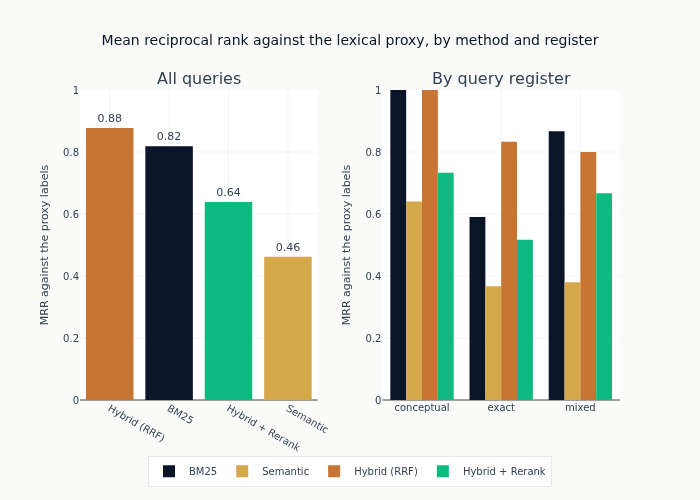

In [39]:
method_order = ["BM25", "Semantic", "Hybrid (RRF)", "Hybrid + Rerank"]
colors = dict(zip(method_order, ml4t_palette(len(method_order), categorical=True), strict=True))

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("All queries", "By query register"),
    horizontal_spacing=0.12,
)
fig.add_trace(
    go.Bar(
        x=overall["method"].to_list(),
        y=overall["avg_mrr"].to_list(),
        marker_color=[colors[m] for m in overall["method"]],
        text=[f"{v:.2f}" for v in overall["avg_mrr"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)
for method in method_order:
    subset = by_type.filter(pl.col("method") == method).sort("query_type")
    fig.add_trace(
        go.Bar(
            name=method,
            x=subset["query_type"].to_list(),
            y=subset["avg_mrr"].to_list(),
            marker_color=colors[method],
        ),
        row=1,
        col=2,
    )

fig.update_layout(
    title="Mean reciprocal rank against the lexical proxy, by method and register",
    height=500,
    showlegend=True,
    legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5),
    barmode="group",
    margin=dict(t=90, b=100),
)
fig.update_yaxes(title_text="MRR against the proxy labels", range=[0, 1], row=1, col=1)
fig.update_yaxes(title_text="MRR against the proxy labels", range=[0, 1], row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two bar panels on a mean-reciprocal-rank scale running from zero to one. Left, over all "
    "queries: the RRF fusion stands highest, BM25 just below it, the reranked pipeline well "
    "below that, and the dense retriever lowest. Right, the same four methods grouped by "
    "register: on the conceptual register BM25 and the fusion both reach the top of the axis; "
    "on the exact register every method falls, BM25 furthest, leaving the fusion highest; on "
    "the mixed register BM25 and the fusion stand close together above the other two. The "
    "dense retriever is the lowest bar in all three groups.",
)

The left panel is the ordering the previous section explained: the two
retrievers closest to the label rule stand highest, and the cross-encoder
pipeline stands below the fusion it reranks. The right panel is the same
ordering register by register, which is where the register names stop
describing what they were named for.

## 9. Query Enhancement: HyDE

**Hypothetical Document Embeddings (HyDE)** generates a hypothetical answer to
the query using an LLM, then embeds that answer instead of the raw query.
This bridges the vocabulary gap between how analysts phrase questions and how
documents express the same information.

**HyDE Workflow**:
1. **Query**: "What are the supply chain risks?"
2. **LLM generates hypothetical answer**: "The company faces significant supply
   chain risks including geographic concentration in Asia..."
3. **Embed the hypothetical answer** (not the original query)
4. **Retrieve documents** similar to the hypothetical answer

**Intended benefit**: bridge a vocabulary gap by embedding an answer-shaped
query representation. **This notebook does not implement or measure HyDE**,
so nothing above bears on whether it works.

**Trade-offs**: it puts a generation call in the retrieval path, so latency
rises and a hallucinated hypothetical steers the search. A lexical fallback
alongside it bounds that.

## 10. Key Insights

### What each method is for

This table is a statement about mechanism, not a ranking derived from the run
above - the run cannot support a ranking, for the reason section 7 measures.

| Query pattern | Mechanism that handles it | Examples |
|---|---|---|
| Tickers, form numbers, accession numbers | BM25: a rare token carries high inverse document frequency | "AAPL 10-K", "Form 8-K" |
| Exact figures and dates | BM25: the digits are tokens | "Q4 2023 revenue" |
| Questions with no distinctive term | Dense: the embedding does not need a shared token | "What are the risks?" |
| Paraphrase | Dense: two phrasings land near each other | "profit margins" against "gross margin" |
| Both at once | Fusion: neither retriever has to win outright | "Apple supply chain Asia risk" |

### What to do with this in production

1. **Get labels before choosing anything.** Section 7 is what a benchmark
   looks like when its labels come from one of the candidates. A hundred
   query-document pairs judged by someone who knows the domain outranks any
   quantity of proxy-scored comparison.

2. **Fuse before you tune.** RRF has one parameter and needs no calibration,
   so it is the cheapest thing to put between two retrievers that disagree.
   Tune k against judged labels, never against a proxy.

3. **Expect a reranker to cost latency and to need its own evidence.** It
   scores each query-candidate pair, so it cannot be precomputed, and here it
   lowered the proxy score. Only judged relevance can say whether that
   reordering is an improvement.

In [40]:
print("=== The run, in one place ===\n")
for method in method_order:
    row = overall.filter(pl.col("method") == method).row(0, named=True)
    hits = int(all_results.filter(pl.col("method") == method)["hits"].sum())
    print(
        f"{method:<16} MRR {row['avg_mrr']:.3f}  recall {row['avg_recall']:.3f}  "
        f"P@{TOP_K} {row['avg_precision']:.3f} (ceiling {precision_ceiling:.2f})  "
        f"{hits} of {total_labels} labelled documents retrieved"
    )
print(
    f"\nRRF constant k={hybrid.rrf_k}; rerank pool {RERANK_CANDIDATES}; "
    f"reranker backend {reranker.backend}"
)
print(f"{len(documents)} documents, {len(TEST_QUERIES)} queries, {total_labels} labels")
print(
    f"Label rule vs BM25 ordering: {bm25_agreement:.2f}; vs dense ordering: {dense_agreement:.2f}"
)

=== The run, in one place ===

BM25             MRR 0.819  recall 0.867  P@10 0.260 (ceiling 0.30)  39 of 45 labelled documents retrieved
Semantic         MRR 0.462  recall 0.533  P@10 0.160 (ceiling 0.30)  24 of 45 labelled documents retrieved
Hybrid (RRF)     MRR 0.878  recall 0.733  P@10 0.220 (ceiling 0.30)  33 of 45 labelled documents retrieved
Hybrid + Rerank  MRR 0.639  recall 0.822  P@10 0.247 (ceiling 0.30)  37 of 45 labelled documents retrieved

RRF constant k=60; rerank pool 50; reranker backend cross_encoder
200 documents, 15 queries, 45 labels
Label rule vs BM25 ordering: 0.84; vs dense ordering: 0.39


### Production Vector Database Support

| Database | Hybrid Support | Notes |
|----------|----------------|-------|
| Pinecone | Native | sparse_values + dense vectors |
| Weaviate | Native | BM25F + vector with alpha blend |
| Qdrant | Native | Sparse + dense with RRF fusion |
| Milvus | Native | Sparse-dense hybrid index |
| ChromaDB | Manual | Requires external BM25 + fusion |
| pgvector | Manual | Combine with pg_trgm for keywords |

LlamaIndex and LangChain provide abstractions for hybrid search
that work across multiple backends.

## Key takeaways

1. **A proxy label rule that shares a retriever's mechanism cannot rank that
   retriever.** Section 7 measures the correlation between the label rule's
   document ordering and each retriever's. The lexical rule and BM25 agree
   far more closely than the rule and the dense encoder, so the table's
   ordering is partly a similarity measurement wearing the clothes of a
   benchmark. This is the most transferable thing in the notebook: it happens
   to any evaluation whose labels are generated by one of the things being
   evaluated.

2. **The register names describe phrasing, not behaviour.** BM25 scores
   higher on the register named for paraphrase than on the one named for
   literal matching. Naming a slice after the retriever you expect to win it
   is a hypothesis, and this run does not support it.

3. **Reciprocal rank fusion needs no calibration.** It reads ranks, never
   scores, so a retriever emitting values in the single digits and one
   emitting cosines contribute equally from equal positions. The constant
   $k=60$ damps the top of each list; it is the only thing to tune, and it
   should be tuned against judged labels.

4. **Precision@k is bounded by the number of labels.** Three labels against
   a top-ten cut puts the ceiling at three in ten. A precision column read
   against one makes every method here look like a failure.

5. **HyDE is described and not measured.** Section 9 says what it would do
   and this notebook does not implement it, so nothing here supports or
   contradicts it.

**Next**: [`04_ragas_evaluation`](04_ragas_evaluation.ipynb) evaluates whole
RAG pipelines on retrieval, grounding and abstention.